# 7 — From Control to Learning

MDPs and environment design · SOC4180 Robot and AI

Hong Jeong

<figure>
<a
href="https://colab.research.google.com/github/gnoejh/soc4180/blob/main/weeks/07-mdp/lab.ipynb"><img
src="https://colab.research.google.com/assets/colab-badge.svg" /></a>
<figcaption>Open In Colab</figcaption>
</figure>

**Before you start, two things:**

1.  **Runtime → Change runtime type → T4 GPU.** Not for training —
    MuJoCo renders video through EGL on Colab, and that needs the GPU
    runtime.
2.  **File → Save a copy in Drive.** This notebook is opened from GitHub
    and is *not* saved. Without a copy, your work disappears when you
    close the tab.

## The hinge of the course

For six weeks you have **derived** controllers. Transforms, kinematics,
a balance model, gains, a filter — every line justified by physics you
worked out.

From today you **specify problems** instead, and let an algorithm find
the controller.

That is not a smaller job. It is a different one, and the failure modes
move: the mathematics stops being where things go wrong, and the
*specification* starts.

Today we write no learning code at all. We write the problem.

------------------------------------------------------------------------

## The Markov decision process

Five pieces:

| Symbol          | Name       | For our robot                           |
|-----------------|------------|-----------------------------------------|
| $\mathcal{S}$   | states     | joint angles, velocities, body attitude |
| $\mathcal{A}$   | actions    | what we send to the servos              |
| $P(s'\mid s,a)$ | transition | **MuJoCo** — we never write this down   |
| $R(s,a)$        | reward     | what we want, expressed as a number     |
| $\gamma$        | discount   | how much the future counts              |

The goal: a policy $\pi(a\mid s)$ maximising expected discounted return
$\mathbb{E}\left[\sum_t \gamma^t r_t\right]$.

**MuJoCo being the transition function is the whole reason this works.**
We do not need to model the dynamics — we can simply run them.

------------------------------------------------------------------------

## The loop, drawn

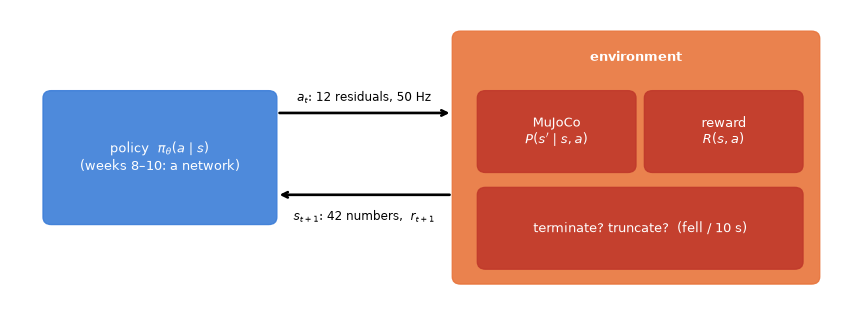

In [1]:
try:
    import soc4180
    import gymnasium
except ImportError:
    %pip install -q "soc4180[env] @ git+https://github.com/gnoejh/soc4180.git"
    import soc4180

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(9, 3.4)); ax.axis("off"); ax.set_xlim(0, 10); ax.set_ylim(0, 4)
def block(x, y, w, h, text, col):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.1", color=col, alpha=0.9))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=10, color="w")
block(0.5, 1.2, 2.6, 1.6, "policy  $\\pi_\\theta(a\\mid s)$\n(weeks 8–10: a network)", "#3b7dd8")
block(5.4, 0.4, 4.2, 3.2, "", "#e8743b")
ax.text(7.5, 3.3, "environment", ha="center", fontsize=10, color="w", weight="bold")
block(5.7, 1.9, 1.7, 0.9, "MuJoCo\n$P(s'\\mid s,a)$", "#c0392b")
block(7.7, 1.9, 1.7, 0.9, "reward\n$R(s,a)$", "#c0392b")
block(5.7, 0.6, 3.7, 0.9, "terminate? truncate?  (fell / 10 s)", "#c0392b")
ax.annotate("", xy=(5.3, 2.6), xytext=(3.2, 2.6), arrowprops=dict(arrowstyle="->", lw=2))
ax.text(4.25, 2.75, "$a_t$: 12 residuals, 50 Hz", ha="center", fontsize=9)
ax.annotate("", xy=(3.2, 1.5), xytext=(5.3, 1.5), arrowprops=dict(arrowstyle="->", lw=2))
ax.text(4.25, 1.15, "$s_{t+1}$: 42 numbers,  $r_{t+1}$", ha="center", fontsize=9)
fig.tight_layout(); plt.show()

Everything inside the orange box is *ours to specify* and nothing inside
it learns. Everything the algorithm touches is the blue box.

------------------------------------------------------------------------

## What $\gamma$ means in seconds

The return from time $t$ is $G_t = \sum_{k \ge 0} \gamma^k\, r_{t+k}$. A
constant reward $r$ sums to $r/(1-\gamma)$, so $1/(1-\gamma)$ is the
**effective horizon**, in decisions:

| $\gamma$ | horizon (decisions) | at 50 Hz                       |
|----------|---------------------|--------------------------------|
| 0.9      | 10                  | 0.2 s — less than one footstep |
| 0.99     | 100                 | 2 s — three footsteps          |
| 0.999    | 1000                | 20 s — longer than the episode |

The same $\gamma$ means a different *time* at a different control rate:
the $0.99$ that suits 50 Hz is a 0.2 s horizon at 500 Hz. That is a
second reason the control rate below is a design decision and not a
detail.

------------------------------------------------------------------------

## Markov, honestly

The Markov property says the current state contains everything needed to
predict the future.

Our robot **violates this**, and knowingly:

- we observe gravity and gyroscope, not true attitude (Week 6)
- we cannot see the ground ahead
- actuator state, contact history, and momentum are only partly visible

Formally we have a *partially observable* MDP. The standard practical
answer is to stack recent observations and include the previous action,
giving the policy a short memory.

**Pretending it is Markov, then compensating, is normal practice.**
Knowing that you are doing it is the difference between engineering and
cargo culting.

------------------------------------------------------------------------

## Design decision 1: what is an action?

Three plausible choices, and they are not equally good:

| Action | Consequence |
|------------------------------------|------------------------------------|
| **Joint torques** | Most general, and the policy must learn gravity compensation from scratch |
| **Absolute joint angles** | Servos do the hard work; but every output must specify a whole posture |
| **Residuals about a nominal pose** | The policy nudges a stance that already works |

We use the third: $\text{target} = q_{\text{nominal}} + \kappa\,a$, with
the nominal being the Week 4 crouch and $\kappa = 0.3$ rad.

An untrained policy outputs roughly zero, which means it **starts by
standing in a sensible crouch** rather than flailing. That single choice
removes an enormous amount of wasted exploration.

------------------------------------------------------------------------

## Design decision 2: how fast does it think?

Physics runs at 500 Hz. Does the policy?

**No.** It runs at **50 Hz**, holding each action for 10 physics steps.

Reasons, all from Week 0’s timescale table:

- a leg cannot move meaningfully in 2 ms, so deciding that often is
  wasted
- a network evaluated at 500 Hz costs 10× the compute for no benefit
- longer intervals mean fewer decisions per episode, so credit
  assignment is easier
- real robots deploy policies at 50 Hz for exactly these reasons

The servos still run at 500 Hz underneath. **The policy sets targets;
the PD loop chases them.** The layered structure from Week 0 survives
intact.

------------------------------------------------------------------------

## Two clocks

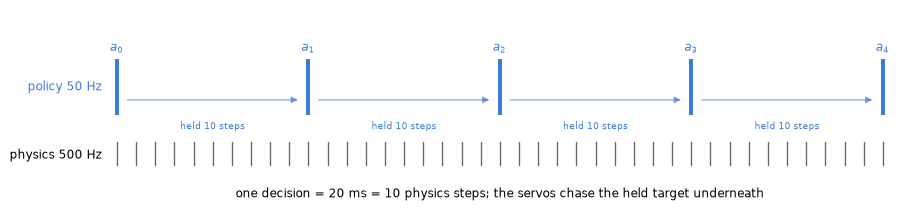

In [2]:
fig, ax = plt.subplots(figsize=(9.6, 2.4)); ax.set_xlim(-1, 41); ax.set_ylim(-0.7, 2.4); ax.axis("off")
for k in range(41):
    ax.plot([k, k], [0, 0.35], color="0.4", lw=1)
ax.text(-0.8, 0.15, "physics 500 Hz", ha="right", va="center", fontsize=9)
for k in range(0, 41, 10):
    ax.plot([k, k], [0.8, 1.6], color="#3b7dd8", lw=3)
    ax.text(k, 1.75, f"$a_{k // 10}$", ha="center", fontsize=9, color="#3b7dd8")
    if k < 40:
        ax.annotate("", xy=(k + 9.6, 1.0), xytext=(k + 0.4, 1.0),
                    arrowprops=dict(arrowstyle="-|>", lw=1, color="#3b7dd8", alpha=0.6))
        ax.text(k + 5, 0.55, "held 10 steps", ha="center", fontsize=7, color="#3b7dd8")
ax.text(-0.8, 1.2, "policy 50 Hz", ha="right", va="center", fontsize=9, color="#3b7dd8")
ax.text(20, -0.5, "one decision = 20 ms = 10 physics steps; the servos chase the held target underneath",
        ha="center", fontsize=9)
fig.tight_layout(); plt.show()

------------------------------------------------------------------------

## Design decision 3: when does an episode end?

- **Terminate** when the robot has fallen — body below 0.5 m, or tilted
  more than 0.7 rad from upright. Continuing to simulate a heap on the
  floor teaches nothing and wastes compute.
- **Truncate** at 10 seconds, so a policy that stands still forever
  still yields a finite episode.

The distinction matters to the algorithm: **termination means the future
is genuinely worth nothing; truncation means we merely stopped
watching.** Bootstrapping past a truncation is correct; bootstrapping
past a termination is a bug that quietly teaches the robot that falling
is survivable.

------------------------------------------------------------------------

## The environment

In [3]:
try:
    import soc4180
    import gymnasium
except ImportError:
    %pip install -q "soc4180[env] @ git+https://github.com/gnoejh/soc4180.git"
    import soc4180

import numpy as np
from soc4180.envs import G1WalkEnv, walker_actions

env = G1WalkEnv()
print(f"observation : {env.observation_space.shape[0]} numbers")
print(f"action      : {env.action_space.shape[0]} (the twelve leg joints only)")
print(f"control     : {1/env.control_dt:.0f} Hz over {1/env.model.opt.timestep:.0f} Hz physics"
      f"  (hold each action {env.decimation} steps)")
print(f"episode     : {env.max_steps} decisions = {env.max_steps*env.control_dt:.0f} s")

observation : 42 numbers
action      : 12 (the twelve leg joints only)
control     : 50 Hz over 500 Hz physics  (hold each action 10 steps)
episode     : 500 decisions = 10 s

Forty-two observations: gravity (3), gyroscope (3), and for each of
twelve joints its angle, velocity, and last commanded residual. **Arms
and waist are frozen** — seventeen dimensions the walking problem does
not need.

------------------------------------------------------------------------

## The observation, drawn to scale

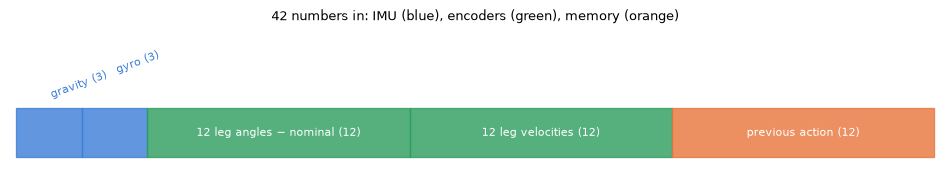

In [4]:
blocks = [("gravity", 3, "#3b7dd8"), ("gyro", 3, "#3b7dd8"),
          ("12 leg angles − nominal", 12, "#2a9d5c"), ("12 leg velocities", 12, "#2a9d5c"),
          ("previous action", 12, "#e8743b")]
fig, ax = plt.subplots(figsize=(10, 2.0)); x = 0
for k, (name, n, col) in enumerate(blocks):
    ax.add_patch(plt.Rectangle((x, 0), n, 1, color=col, alpha=0.8))
    if n > 4:
        ax.text(x + n / 2, 0.5, f"{name} ({n})", ha="center", va="center", fontsize=8, color="w")
    else:
        ax.text(x + n / 2, 1.15 + 0.5 * k, f"{name} ({n})", ha="left", va="bottom", fontsize=8,
                color=col, rotation=20)
    x += n
ax.set_xlim(-0.3, x + 0.3); ax.set_ylim(-0.3, 2.6); ax.axis("off")
ax.set_title(f"{x} numbers in: IMU (blue), encoders (green), memory (orange)", fontsize=10)
fig.tight_layout(); plt.show()

Compare it with week 6’s 64: the arms and the waist are gone, and the
**previous action** has been added — the one-step memory that papers
over the missing Markov property.

------------------------------------------------------------------------

## Validate the contract

Gymnasium ships a checker. Use it, every time.

In [5]:
from gymnasium.utils.env_checker import check_env
check_env(env.unwrapped, skip_render_check=True)
print("env_checker: PASSED")

env_checker: PASSED

It verifies the boring things that silently break training: shapes and
dtypes matching the declared spaces, `reset` accepting a seed and
returning `(obs, info)`, `step` returning five values, and determinism
given a seed.

A subtly non-conforming environment does not crash. **It trains badly,
and you spend a week blaming the algorithm.**

------------------------------------------------------------------------

## Two baselines before any learning

In [6]:
def rollout(policy, seed=0):
    obs, _ = env.reset(seed=seed)
    total, steps = 0.0, 0
    while True:
        obs, r, terminated, truncated, _ = env.step(policy(steps))
        total += r; steps += 1
        if terminated or truncated:
            return total, steps, terminated

zero = lambda k: np.zeros(env.action_space.shape[0], dtype=np.float32)
rand = lambda k: env.action_space.sample()

for name, pol in (("do nothing (hold the crouch)", zero), ("uniform random", rand)):
    R, n, fell = rollout(pol)
    print(f"  {name:30s} return {R:8.2f}  {n:3d} steps  "
          f"{'FELL' if fell else 'survived'}")

  do nothing (hold the crouch)   return   774.09  500 steps  survived
  uniform random                 return    22.47   25 steps  FELL

**Always measure these first.** “Do nothing” is the number a policy must
beat to have learned anything at all; random is the number it must beat
to be a policy.

------------------------------------------------------------------------

## Can the env even express what we know?

We already have a working controller. If the environment cannot
represent it, no algorithm will find anything better.

In [7]:
from soc4180.walking import WalkingController, GaitParams

def walker_in_env(action_scale=0.3, control_hz=50.0):
    e = G1WalkEnv(episode_seconds=12.0, action_scale=action_scale, control_hz=control_hz)
    c = WalkingController(e.model, GaitParams(n_steps=12))
    e.reset(); clipped, steps = 0, 0
    while True:
        a = walker_actions(e, c, e.data.time)
        clipped += int(np.any(np.abs(a) >= 0.999)); steps += 1
        _, _, term, trunc, _ = e.step(a)
        if term or trunc:
            return e.data.qpos[0], e.data.qpos[2], 100*clipped/steps, term

x, z, clip, fell = walker_in_env()
print(f"analytic walker inside the env: travelled {x:+.3f} m, pelvis {z:.3f} m")
print(f"  {'FELL' if fell else 'survived'};  actions hit the limit on {clip:.1f}% of steps")
print(f"  (at 500 Hz with no action limit it walks +0.99 m)")

analytic walker inside the env: travelled +0.239 m, pelvis 0.561 m
  FELL;  actions hit the limit on 35.7% of steps
  (at 500 Hz with no action limit it walks +0.99 m)

**It falls.** The controller that worked three weeks ago cannot survive
its own environment.

------------------------------------------------------------------------

## Diagnose it

Two suspects: the action range is too narrow, and the control rate is
too slow. Separate them.

In [8]:
grid = {}
print(f"{'scale':>6} {'Hz':>5} {'travel':>8} {'z':>7} {'clipped':>8}  outcome")
for scale in (0.3, 0.6, 1.0):
    for hz in (50, 100, 200):
        x, z, clip, fell = walker_in_env(scale, hz)
        grid[(scale, hz)] = (x, clip, fell)
        print(f"{scale:6.1f} {hz:5d} {x:+8.3f} {z:7.3f} {clip:7.1f}%  "
              f"{'FELL' if fell else 'survived'}")

 scale    Hz   travel       z  clipped  outcome
   0.3    50   +0.239   0.561    35.7%  FELL
   0.3   100   +0.213   0.575    35.1%  FELL
   0.3   200   +0.234   0.562    35.9%  FELL
   0.6    50   +1.553   0.557    18.1%  FELL
   0.6   100   +1.567   0.564    19.1%  FELL
   0.6   200   +1.560   0.571    19.1%  FELL
   1.0    50   +1.564   0.564     0.0%  FELL
   1.0   100   +1.047   0.717     0.0%  survived
   1.0   200   +1.049   0.717     0.0%  survived

**Both matter, independently.** At $\kappa=0.3$ a third of the actions
are clipped and it fails at every rate. At $\kappa=1.0$ clipping stops,
but 50 Hz still fails. Only $\kappa=1.0$ **and** ≥100 Hz reproduces the
walk — 1.05 m, against 0.99 m at 500 Hz.

------------------------------------------------------------------------

## The same table, as a picture

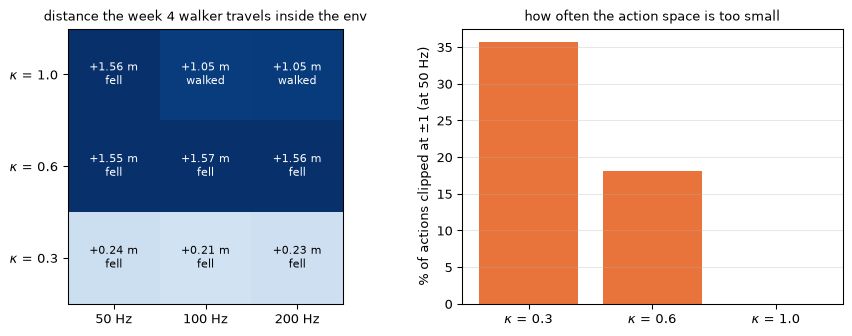

In [9]:
scales, rates = (0.3, 0.6, 1.0), (50, 100, 200)
dist = np.array([[grid[(s, hz)][0] for hz in rates] for s in scales])
clip = np.array([[grid[(s, hz)][1] for hz in rates] for s in scales])
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(9.6, 3.6), gridspec_kw={"width_ratios": [1.3, 1]})
ax0.imshow(dist, cmap="Blues", vmin=0, vmax=1.1, origin="lower")
for i, s in enumerate(scales):
    for j, hz in enumerate(rates):
        x, c, fell = grid[(s, hz)]
        ax0.text(j, i, f"{x:+.2f} m\n{'fell' if fell else 'walked'}", ha="center", va="center",
                 fontsize=8, color="w" if x > 0.6 else "k")
ax0.set_xticks(range(3), [f"{hz} Hz" for hz in rates])
ax0.set_yticks(range(3), [f"$\\kappa$ = {s}" for s in scales])
ax0.set_title("distance the week 4 walker travels inside the env", fontsize=10)
ax1.bar([f"$\\kappa$ = {s}" for s in scales], clip[:, 0], color="#e8743b")
ax1.set_ylabel("% of actions clipped at ±1 (at 50 Hz)")
ax1.set_title("how often the action space is too small", fontsize=10); ax1.grid(axis="y", alpha=0.3)
fig.tight_layout(); plt.show()

Only the top-right corner walks. Reading down the right column: the rate
was fine and the actions were being cut off. Reading across the top row:
the actions were fine and the rate was too slow. Two separate
constraints, each sufficient to break it.

------------------------------------------------------------------------

## What that experiment actually taught

**Your action space defines the set of reachable behaviours.** A
solution outside it is not merely hard to find; it does not exist in
your problem. Nothing in a learning curve will ever tell you this — the
run just plateaus.

So why keep $\kappa = 0.3$ and 50 Hz as our defaults?

Because those are the values the locomotion literature trains with, and
learned policies *do* find good gaits inside that envelope. They simply
find **different gaits from ours** — smaller, faster corrections rather
than large scripted swings.

The lesson is not “our defaults are wrong”. It is that an environment is
a **commitment about what kind of solution you expect**, and you should
know what you have committed to.

------------------------------------------------------------------------

## One trap in that table

Compare returns across the three control rates. They differ by roughly
5×.

Nothing got better. **A 200 Hz episode contains four times as many steps
as a 50 Hz one**, and each step adds reward.

> Return is only comparable between runs that share an episode
> structure.

Report metrics that mean something physically — distance travelled, time
upright, average velocity — alongside return. Week 9 leans on this hard.

------------------------------------------------------------------------

## The reward, for now

In [10]:
env.reset()
_, _, _, _, info = env.step(np.zeros(12, dtype=np.float32))
for key, value in info.items():
    print(f"  {key:18s} {value:+.4f}")

  forward_velocity   +0.0523
  tracking           +0.4485
  upright            +0.9999
  effort             +0.0000
  smooth             +0.0000
  alive              +1.0000
  stand_still        +1.0000
  air_time           +0.0000

Four terms and an alive bonus:

- **track** a target forward velocity — the actual objective
- stay **upright** — shaping, to make early learning less hopeless
- pay for **effort** and for **jerky** actions — so it does not thrash
- **alive bonus** — so early death is worse than mediocre survival

Every one of those is a decision, and every one is exploitable. **Week 9
breaks them on purpose.**

------------------------------------------------------------------------

## The shape of each term

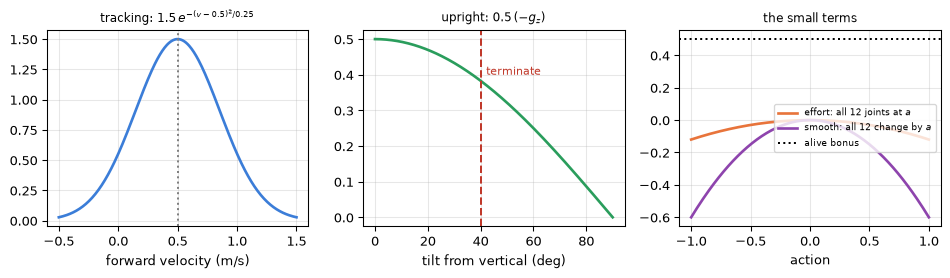

In [11]:
from soc4180.envs import DEFAULT_REWARD
v = np.linspace(-0.5, 1.5, 300); tilt = np.linspace(0, 90, 300); a = np.linspace(-1, 1, 200)
fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(10, 3.0))
ax0.plot(v, DEFAULT_REWARD["tracking"] * np.exp(-((v - env.target_velocity) ** 2) / 0.25), lw=2, color="#3b7dd8")
ax0.axvline(env.target_velocity, color="0.5", ls=":"); ax0.set_xlabel("forward velocity (m/s)")
ax0.set_title("tracking: $1.5\\,e^{-(v-0.5)^2/0.25}$", fontsize=9)
ax1.plot(tilt, DEFAULT_REWARD["upright"] * np.cos(np.radians(tilt)), lw=2, color="#2a9d5c")
ax1.axvline(np.degrees(env.max_tilt), color="#c0392b", ls="--")
ax1.text(np.degrees(env.max_tilt) + 2, 0.4, "terminate", color="#c0392b", fontsize=8)
ax1.set_xlabel("tilt from vertical (deg)"); ax1.set_title("upright: $0.5\\,(-g_z)$", fontsize=9)
ax2.plot(a, DEFAULT_REWARD["effort"] * 12 * a**2, lw=2, color="#e8743b", label="effort: all 12 joints at $a$")
ax2.plot(a, DEFAULT_REWARD["smooth"] * 12 * a**2, lw=2, color="#8e44ad", label="smooth: all 12 change by $a$")
ax2.axhline(DEFAULT_REWARD["alive"], color="k", ls=":", label="alive bonus")
ax2.set_xlabel("action"); ax2.legend(fontsize=7, loc="center right"); ax2.set_title("the small terms", fontsize=9)
for ax in (ax0, ax1, ax2):
    ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

Read the vertical scales. Tracking is worth up to 1.5 per step, upright
0.5, alive 0.5; effort costs at most 0.12 even flat out. The reward is
dominated by *going the right speed while standing up* — which is what
makes standing still worth 776 and walking 1250, next week’s two
numbers.

------------------------------------------------------------------------

## Lab class: on your laptop

``` bash
uv run weeks/07-mdp/lab_env.py
```

`G1WalkEnv`, stepping at 50 Hz in real time in the viewer. Keys `1`–`4`
pick a policy: hold the crouch, uniform random, the week 4 walker as
actions, and `my_policy` — a function from the 42-number observation to
12 residuals.

On the robot: a white arrow for `obs[0:3]` (gravity, as the policy sees
it), a bar above the head for this step’s reward, and yellow feet when
the env counts them as airborne. Every episode ends with return, steps,
and **terminated** or **truncated**.

| Step | Do | Right looks like |
|------------------------|------------------------|------------------------|
| 1 | `1`, `2`, `3`; then `ACTION_SCALE = 1.0`, `CONTROL_HZ = 100`, `3` | the walker falls, then walks; the student says why |
| 2 | `my_policy` = bend the knees | `ENTER`: upright up, effort down, tracking unchanged |
| 3 | `my_policy` periodic on hip pitch | a termination, read off the episode line |
| 4 | `my_policy` leans the hips against `obs[0:3]` | survives a ctrl-drag push that policy `1` does not |
| 5 | `REWARD_WEIGHTS = {"alive": 0.0}` | the numbers change and the behaviour does not; the student says why |

------------------------------------------------------------------------

## Exercises

1.  **Termination as a reward.** Remove the alive bonus. Does the policy
    space change, or only the incentives? Predict before running.
2.  **Observation ablation.** Remove the previous action from the
    observation. Argue whether the problem is still (approximately)
    Markov.
3.  **Torque actions.** Add a mode that outputs torques instead of
    residuals. Roll out the zero action in each. Why does one stand and
    the other collapse?
4.  **Find the rate limit.** Bisect the control rate between 50 and 100
    Hz at $\kappa = 1.0$. Where exactly does the walker start surviving?
5.  **Fair comparison.** Design a metric that compares 50 Hz and 200 Hz
    runs honestly. Show it ranks the runs differently from raw return.
6.  **Truncation bug.** Explain what a policy would learn if truncation
    were treated as termination. Which of our four reward terms would it
    exploit?

------------------------------------------------------------------------

## Next week

**08 — policy gradients and PPO.** The environment is written and
checked, the baselines are measured, and we know what it can and cannot
express.

Now we let an algorithm search it — starting on something far easier
than a humanoid, so that when PPO meets the hard problem you already
know what a healthy learning curve looks like.